## **Praktikum Mandiri 10 | ML Senin Pagi**

Nama : Rika Rahma

NIM : 0110222134

Rombel : TI08 - 2022

### **Latihan 1**

1. Import Library

In [106]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.preprocessing import LabelEncoder
import joblib
import os

2. Dataset

In [107]:
# Persiapan Dataset
data = {
    'Temperatur Udara (°C)': [10, 25, 15, 20, 18, 20, 22, 24],
    'Kecepatan Angin (km/jam)': [0, 0, 5, 3, 7, 10, 5, 6],
    'Klasifikasi (Persepsi Marry)': ['Dingin', 'Panas', 'Dingin', 'Dingin',
                                    'Dingin', 'Panas', 'Panas', 'Panas']
}

df = pd.DataFrame(data)
print("Dataset Awal:\n", df)

Dataset Awal:
    Temperatur Udara (°C)  Kecepatan Angin (km/jam)  \
0                     10                         0   
1                     25                         0   
2                     15                         5   
3                     20                         3   
4                     18                         7   
5                     20                        10   
6                     22                         5   
7                     24                         6   

  Klasifikasi (Persepsi Marry)  
0                       Dingin  
1                        Panas  
2                       Dingin  
3                       Dingin  
4                       Dingin  
5                        Panas  
6                        Panas  
7                        Panas  


In [108]:
# Encoding Label
le = LabelEncoder()
df['Klasifikasi_encoded'] = le.fit_transform(df['Klasifikasi (Persepsi Marry)'])  # Dingin -> 0, Panas -> 1
print("\nDataset setelah Encoding:\n", df)


Dataset setelah Encoding:
    Temperatur Udara (°C)  Kecepatan Angin (km/jam)  \
0                     10                         0   
1                     25                         0   
2                     15                         5   
3                     20                         3   
4                     18                         7   
5                     20                        10   
6                     22                         5   
7                     24                         6   

  Klasifikasi (Persepsi Marry)  Klasifikasi_encoded  
0                       Dingin                    0  
1                        Panas                    1  
2                       Dingin                    0  
3                       Dingin                    0  
4                       Dingin                    0  
5                        Panas                    1  
6                        Panas                    1  
7                        Panas                    1  

3. Pisahkan Fitur dan Target

In [109]:
# Pisah Fitur dan Target
X = df[['Temperatur Udara (°C)', 'Kecepatan Angin (km/jam)']]
y = df['Klasifikasi_encoded']

In [110]:
# Data Test
test_data = np.array([[16, 3]])
print("\nData Test:", test_data)


Data Test: [[16  3]]


4. Evaluasi Nilai K dengan LOOCV

In [111]:
# Evaluasi Nilai K dengan LOOCV
loo = LeaveOneOut()
k_values = list(range(1, len(X)))  # K=1 hingga 7
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=loo, scoring='accuracy')
    cv_scores.append(scores.mean())

In [112]:
# Pilih Best K
best_k_index = np.nanargmax(cv_scores)
best_k = k_values[best_k_index]
best_score = np.nanmax(cv_scores)
print("\nAkurasi CV untuk setiap K:", cv_scores)
print(f"Best K: {best_k} dengan akurasi: {best_score}")


Akurasi CV untuk setiap K: [np.float64(0.625), np.float64(0.5), np.float64(0.625), np.float64(0.625), np.float64(0.625), np.float64(0.25), np.float64(0.0)]
Best K: 1 dengan akurasi: 0.625


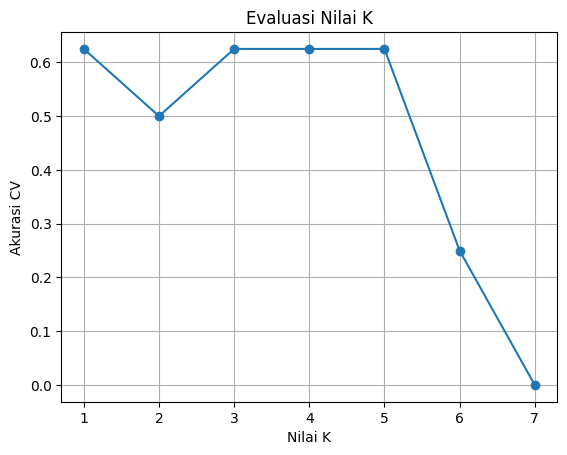

In [113]:
import os

# Visualisasi Akurasi vs K
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel('Nilai K')
plt.ylabel('Akurasi CV')
plt.title('Evaluasi Nilai K')
plt.grid(True)

5. Training Model

In [114]:
# Training Model dengan Best K
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X, y)

KNeighborsClassifier(n_neighbors=1)

6. Prediksi Data Test

In [115]:
# Prediksi Data Test
prediction = knn_best.predict(test_data)
predicted_class = le.inverse_transform(prediction)[0]
print(f"\nPrediksi untuk data test (16°C, 3 km/jam): {predicted_class}")


Prediksi untuk data test (16°C, 3 km/jam): Dingin


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


### **Latihan 2**

1. Import Library

In [116]:
# Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import os

2. Dataset

In [131]:
data = {
    'NIM': ['TI001','TI002','TI003','TI004','TI005','TI006','TI007','TI008','TI009','TI010'],
    'Hasil Sebenarnya': ['Lulus','Lulus','Lulus','Lulus','Lulus',
                         'Tidak Lulus','Tidak Lulus','Tidak Lulus','Tidak Lulus','Tidak Lulus'],
    'Hasil Prediksi':   ['Lulus','Lulus','Lulus','Tidak Lulus','Tidak Lulus',
                         'Lulus','Tidak Lulus','Tidak Lulus','Tidak Lulus','Tidak Lulus']
}

df = pd.DataFrame(data)
print("Dataset(10 Mahasiswa):")
print(df)
print("\n")

Dataset(10 Mahasiswa):
     NIM Hasil Sebenarnya Hasil Prediksi
0  TI001            Lulus          Lulus
1  TI002            Lulus          Lulus
2  TI003            Lulus          Lulus
3  TI004            Lulus    Tidak Lulus
4  TI005            Lulus    Tidak Lulus
5  TI006      Tidak Lulus          Lulus
6  TI007      Tidak Lulus    Tidak Lulus
7  TI008      Tidak Lulus    Tidak Lulus
8  TI009      Tidak Lulus    Tidak Lulus
9  TI010      Tidak Lulus    Tidak Lulus




3. Preprocessing & Training KNN

In [118]:
le = LabelEncoder()
y = le.fit_transform(df['Hasil Sebenarnya'])  # Lulus=1, Tidak Lulus=0

In [119]:
X = np.array(range(len(df))).reshape(-1, 1)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X, y)

KNeighborsClassifier(n_neighbors=3)

4. Prediction

In [120]:
# Prediksi menggunakan KNN
prediksi_encoded = knn.predict(X)
df['Prediksi KNN'] = le.inverse_transform(prediksi_encoded)
print("Hasil Prediksi KNN (K=3):")
print(df[['NIM', 'Hasil Sebenarnya', 'Hasil Prediksi', 'Prediksi KNN']])

Hasil Prediksi KNN (K=3):
     NIM Hasil Sebenarnya Hasil Prediksi Prediksi KNN
0  TI001            Lulus          Lulus        Lulus
1  TI002            Lulus          Lulus        Lulus
2  TI003            Lulus          Lulus        Lulus
3  TI004            Lulus    Tidak Lulus        Lulus
4  TI005            Lulus    Tidak Lulus        Lulus
5  TI006      Tidak Lulus          Lulus  Tidak Lulus
6  TI007      Tidak Lulus    Tidak Lulus  Tidak Lulus
7  TI008      Tidak Lulus    Tidak Lulus  Tidak Lulus
8  TI009      Tidak Lulus    Tidak Lulus  Tidak Lulus
9  TI010      Tidak Lulus    Tidak Lulus  Tidak Lulus


5. Confusion Matrix + Heatmap

In [121]:
# Confusion Matrix
cm = confusion_matrix(df['Hasil Sebenarnya'], df['Hasil Prediksi'], labels=['Lulus', 'Tidak Lulus'])
print("\nTabel Confusion Matrix:")
print(cm)


Tabel Confusion Matrix:
[[3 2]
 [1 4]]


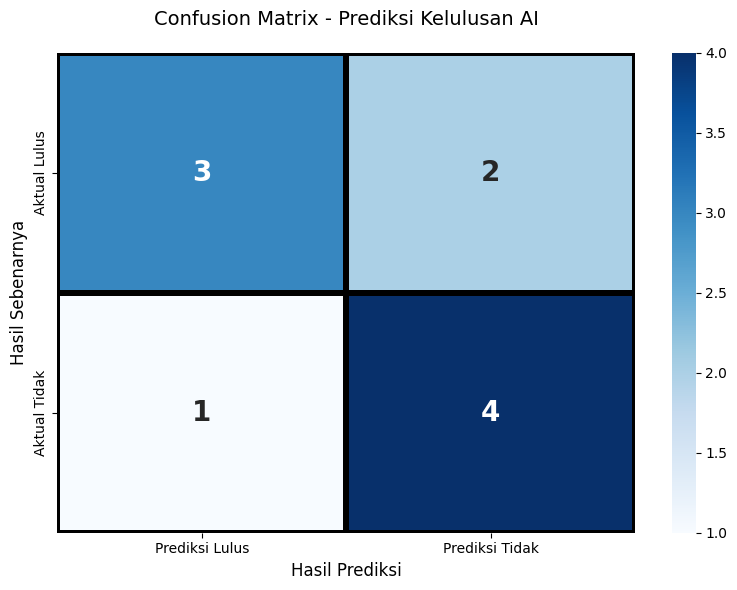

In [122]:
# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=3, linecolor='black',
            xticklabels=['Prediksi Lulus', 'Prediksi Tidak'],
            yticklabels=['Aktual Lulus', 'Aktual Tidak'],
            annot_kws={"size": 20, "weight": "bold"})
plt.title('Confusion Matrix - Prediksi Kelulusan AI', fontsize=14, pad=20)
plt.ylabel('Hasil Sebenarnya', fontsize=12)
plt.xlabel('Hasil Prediksi', fontsize=12)
plt.tight_layout()
plt.savefig('reports/latihan2_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

6. Hitung Nilai Persentase

In [123]:
# Hitung Nilai
acc = accuracy_score(df['Hasil Sebenarnya'], df['Hasil Prediksi']) * 100
precision = cm[0,0] / (cm[0,0] + cm[1,0]) * 100 if (cm[0,0] + cm[1,0]) > 0 else 0
recall = cm[0,0] / (cm[0,0] + cm[0,1]) * 100 if (cm[0,0] + cm[0,1]) > 0 else 0

print("\n" + "="*50)
print("HASIL PERHITUNGAN PERSENTASE")
print("="*50)
print(f"Accuracy  = {acc:.1f}%")
print(f"Precision = {precision:.1f}%")
print(f"Recall    = {recall:.1f}%")
print("="*50)

print("\nClassification Report:")
print(classification_report(df['Hasil Sebenarnya'], df['Hasil Prediksi']))


HASIL PERHITUNGAN PERSENTASE
Accuracy  = 70.0%
Precision = 75.0%
Recall    = 60.0%

Classification Report:
              precision    recall  f1-score   support

       Lulus       0.75      0.60      0.67         5
 Tidak Lulus       0.67      0.80      0.73         5

    accuracy                           0.70        10
   macro avg       0.71      0.70      0.70        10
weighted avg       0.71      0.70      0.70        10



### **Latihan 3**

1. Import Library

In [150]:
# Import Library
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

2. Dataset

In [151]:
data = {
    'Temperature': [14.0, 39.0, 30.0, 38.0, 27.0, 32.0, -2.0, 3.0, 3.0, 28.0],
    'Humidity':    [73,96,64,83,74,55,97,85,83,74],
    'Wind Speed':  [9.5,8.5,7.0,1.5,17.0,3.5,8.0,6.0,6.0,8.5],
    'Precipitation (%)': [82.0,71.0,16.0,82.0,66.0,26.0,86.0,96.0,66.0,107.0],
    'Cloud Cover': ['partly cloudy','partly cloudy','clear','clear','overcast',
                    'overcast','overcast','partly cloudy','overcast','clear'],
    'Atmospheric Pressure': [1010.82,1011.43,1018.72,1026.25,990.67,1010.03,990.87,984.46,999.44,1012.13],
    'UV Index': [2,7,5,7,1,2,1,1,0,8],
    'Season': ['Winter','Spring','Spring','Spring','Winter','Summer','Winter','Winter','Winter','Winter'],
    'Visibility (km)': [3.5,10.0,5.5,1.0,2.5,5.0,4.0,3.5,1.0,7.5],
    'Location': ['inland','inland','mountain','coastal','mountain','inland','inland','inland','mountain','coastal'],
    'Weather Type': ['Rainy','Cloudy','Sunny','Sunny','Rainy','Cloudy','Snowy','Snowy','Snowy','Sunny']
}

df = pd.DataFrame(data)
print("DATASET LATIHAN 3:")
print(df)
print("\n")

DATASET LATIHAN 3:
   Temperature  Humidity  Wind Speed  Precipitation (%)    Cloud Cover  \
0         14.0        73         9.5               82.0  partly cloudy   
1         39.0        96         8.5               71.0  partly cloudy   
2         30.0        64         7.0               16.0          clear   
3         38.0        83         1.5               82.0          clear   
4         27.0        74        17.0               66.0       overcast   
5         32.0        55         3.5               26.0       overcast   
6         -2.0        97         8.0               86.0       overcast   
7          3.0        85         6.0               96.0  partly cloudy   
8          3.0        83         6.0               66.0       overcast   
9         28.0        74         8.5              107.0          clear   

   Atmospheric Pressure  UV Index  Season  Visibility (km)  Location  \
0               1010.82         2  Winter              3.5    inland   
1               1011.4

3. Preprocessing (Encoding + Scalling)

In [152]:
encoders = {}

for col in ['Cloud Cover', 'Season', 'Location', 'Weather Type']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le    # simpan encoder agar bisa inverse transform

# Target (encoded)
y = df['Weather Type']

# Fitur (numerik + hasil encoding)
X = df.drop(columns=['Weather Type'])

In [153]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

4. Training KNN

In [164]:
# Training KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_scaled, y)

KNeighborsClassifier(n_neighbors=3)

5. Prediksi

In [166]:
y_pred = knn.predict(X_scaled)

# decode prediksi agar terbaca
y_pred_text = encoders['Weather Type'].inverse_transform(y_pred)
df['Prediksi KNN'] = y_pred_text

print("HASIL PREDIKSI KNN:")
print(df[['Temperature','Humidity','Weather Type','Prediksi KNN']])
print("\n")

HASIL PREDIKSI KNN:
   Temperature  Humidity  Weather Type Prediksi KNN
0         14.0        73             1        Snowy
1         39.0        96             0       Cloudy
2         30.0        64             3        Sunny
3         38.0        83             3        Sunny
4         27.0        74             1        Rainy
5         32.0        55             0       Cloudy
6         -2.0        97             2        Snowy
7          3.0        85             2        Snowy
8          3.0        83             2        Snowy
9         28.0        74             3        Sunny




6. Akurasi Model

In [156]:
# Akurasi Model
accuracy = accuracy_score(y, y_pred) * 100
print(f"AKURASI MODEL KNN = {accuracy:.1f}%")
print("\nCLASSIFICATION REPORT:")
print(classification_report(y, y_pred))
print("\n")

AKURASI MODEL KNN = 90.0%

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      0.50      0.67         2
           2       0.75      1.00      0.86         3
           3       1.00      1.00      1.00         3

    accuracy                           0.90        10
   macro avg       0.94      0.88      0.88        10
weighted avg       0.93      0.90      0.89        10





7. Confusion Matrix + Heatmap

In [158]:
# Confusion Matrix
y_true_decoded = encoders['Weather Type'].inverse_transform(y)

cm = confusion_matrix(y_true_decoded, df['Prediksi KNN'],
                      labels=['Rainy', 'Cloudy', 'Sunny', 'Snowy'])

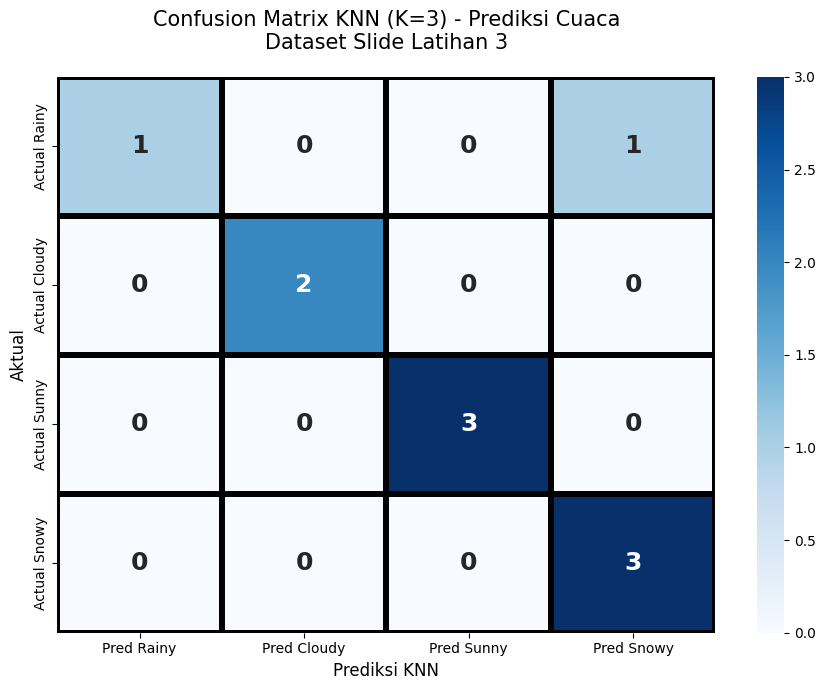

In [159]:
# Heatmap
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=3, linecolor='black',
            xticklabels=['Pred Rainy', 'Pred Cloudy', 'Pred Sunny', 'Pred Snowy'],
            yticklabels=['Actual Rainy', 'Actual Cloudy', 'Actual Sunny', 'Actual Snowy'],
            annot_kws={"size": 18, "weight": "bold"})
plt.title('Confusion Matrix KNN (K=3) - Prediksi Cuaca\nDataset Slide Latihan 3',
          fontsize=15, pad=20)
plt.ylabel('Aktual', fontsize=12)
plt.xlabel('Prediksi KNN', fontsize=12)
plt.tight_layout()
plt.savefig('reports/latihan3_knn_cuaca_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()